### Fase 1: Construcción y depuración de la base de datos maestra

#### Paso 1.1: Consolidación de datos

In [19]:
import pandas as pd

datos= pd.read_csv('/home/hjvargaso/proyectos/tesis_sequia_2/data/raw/db_climapy.csv')
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 166780 entries, 0 to 166779
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Código    166780 non-null  int64  
 1   Estación  166780 non-null  str    
 2   Año       166780 non-null  int64  
 3   Mes       166780 non-null  int64  
 4   Día       166780 non-null  str    
 5   Date      163759 non-null  str    
 6   tmin_C    162056 non-null  float64
 7   tmax_C    160915 non-null  float64
 8   tmed_C    162117 non-null  float64
 9   rain_mm   161994 non-null  float64
 10  hum_%     153445 non-null  float64
 11  pa_hpa    155135 non-null  float64
 12  Season    163759 non-null  str    
 13  Ciclo     163759 non-null  float64
dtypes: float64(7), int64(3), str(4)
memory usage: 17.8 MB


##### Seleccionar variables y renombrar

In [20]:
df = datos[['Código', 'Date', 'rain_mm', 'tmed_C', 'tmin_C', 'tmax_C']]
df.columns = ['estacion_id', 'fecha', 'lluvia', 'temp_med', 'temp_min', 'temp_max']
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166780 entries, 0 to 166779
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   estacion_id  166780 non-null  int64  
 1   fecha        163759 non-null  str    
 2   lluvia       161994 non-null  float64
 3   temp_med     162117 non-null  float64
 4   temp_min     162056 non-null  float64
 5   temp_max     160915 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 7.6 MB


##### Código de las estaciones

In [21]:
# Cantidad de valores únicos en la columna 'estacion_id'
cantidad_unicos = df['estacion_id'].nunique()
print(f"Cantidad de valores únicos: {cantidad_unicos} \n")

# Mostrar valores únicos y sus cantidades
print( "Valores únicos y sus conteos:")
df['estacion_id'].value_counts()

Cantidad de valores únicos: 19 

Valores únicos y sus conteos:


estacion_id
86068    8928
86086    8928
86097    8928
86134    8928
86170    8928
86192    8928
86218    8928
86234    8928
86246    8928
86255    8928
86268    8928
86285    8928
86128    8897
86233    8897
86210    8866
86260    8866
86297    8773
86185    8742
86221    6603
Name: count, dtype: int64

In [22]:
# Identificar nombre de estaciones
dic_estaciones= datos[['Código', 'Estación']].drop_duplicates().set_index('Código')['Estación'].to_dict()
print(dic_estaciones)


{86068: 'Aeropuerto de Mariscal Estigarribia', 86086: 'Puerto Casado', 86097: 'Aeródromo de Pedro Juan Caballero', 86128: 'Pozo Colorado', 86134: 'Aeródromo de Concepción', 86170: 'Gral. José María Bruguez', 86185: 'Aeródromo de San Pedro del Ycuamandyyú', 86192: 'San Estanislao', 86210: 'Aeródromo de Salto del Guairá', 86218: 'Aeropuerto Internacional Silvio Pettirossi', 86221: 'Paraguarí', 86233: 'Villarrica del Espiritu Santo', 86234: 'Coronel Oviedo', 86246: 'Aeropuerto Internacional Guaraní Minga Guazú', 86255: 'Aeródromo de Pilar', 86260: 'San Juan Bautista', 86268: 'Caazapá', 86285: 'Base Aérea de Capitán Meza', 86297: 'Encarnación'}


In [23]:
# Nuevo nombre de estaciones metereológicas
nombres_estaciones = {
86068: 'MCAL', 
86086: 'PTOC', 
86097: 'PJC', 
86128: 'PCOL', 
86134: 'CONC', 
86170: 'GBRU', 
86185: 'SPED', 
86192: 'SEST', 
86210: 'SGUA', 
86218: 'LUQUE', 
86221: 'PARA', 
86233: 'VILL', 
86234: 'COVIE', 
86246: 'MINGA', 
86255: 'PILAR', 
86260: 'SJBA', 
86268: 'CAAZ', 
86285: 'CMEZA', 
86297: 'ENCAR'}

# Reemplazar en el DataFrame
df = df.copy()
df['estacion_id'] = df['estacion_id'].replace(nombres_estaciones)

#### Paso 1.2: Limpieza y estandarización inicial

In [24]:
# La columna de fecha debe ser un objeto datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166780 entries, 0 to 166779
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   estacion_id  166780 non-null  object        
 1   fecha        163759 non-null  datetime64[us]
 2   lluvia       161994 non-null  float64       
 3   temp_med     162117 non-null  float64       
 4   temp_min     162056 non-null  float64       
 5   temp_max     160915 non-null  float64       
dtypes: datetime64[us](1), float64(4), object(1)
memory usage: 7.6+ MB


##### Paso 1.3: Revisar datos nulos o duplicados de fechas

In [25]:
import numpy as np

# 1. Definir el rango teórico del panel (2000-01-01 a 2023-12-31)
fecha_inicio = '2000-01-01'
fecha_fin = '2023-12-31'
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')
total_dias_esperados = len(rango_completo)

print(f"Total de días esperados por estación: {total_dias_esperados}")

# 2. Identificar registros con fecha nula
nulos_fecha = df['fecha'].isnull().sum()
print(f"Registros con fecha nula: {nulos_fecha}")

# 3. Identificar si existen duplicados (misma estación y misma fecha)
# Primero filtramos las fechas no nulas para evitar distorsiones
df_sin_nulos = df.dropna(subset=['fecha'])
duplicados = df_sin_nulos.duplicated(subset=['estacion_id', 'fecha']).sum()
print(f"Registros duplicados (misma estación y fecha): {duplicados}")

Total de días esperados por estación: 8766
Registros con fecha nula: 3021
Registros duplicados (misma estación y fecha): 0


#### 1.3. Análisis de cobertura temporal por estación:

In [26]:
# Agrupar por estación para obtener métricas de cobertura
diagnostico_estaciones = df_sin_nulos.groupby('estacion_id').agg(
    fecha_minima=('fecha', 'min'),
    fecha_maxima=('fecha', 'max'),
    dias_observados=('fecha', 'nunique')  # Cuenta días únicos con registro
).reset_index()

# Calcular métricas de completitud respecto al rango teórico completo (2000-2023)
diagnostico_estaciones['dias_esperados'] = total_dias_esperados
diagnostico_estaciones['dias_faltantes'] = diagnostico_estaciones['dias_esperados'] - diagnostico_estaciones['dias_observados']
diagnostico_estaciones['porcentaje_completitud'] = (diagnostico_estaciones['dias_observados'] / total_dias_esperados) * 100

# Ordenar por menor completitud para identificar las estaciones más críticas
diagnostico_estaciones = diagnostico_estaciones.sort_values(by='porcentaje_completitud')
diagnostico_estaciones.head(19)

,estacion_id,fecha_minima,fecha_maxima,dias_observados,dias_esperados,dias_faltantes,porcentaje_completitud
9,PARA,2006-04-01,2023-12-31,6484,8766,2282,73.967602
17,SPED,2000-01-01,2023-12-31,8584,8766,182,97.923796
4,ENCAR,2000-01-01,2023-12-31,8616,8766,150,98.288843
15,SGUA,2000-01-01,2023-12-31,8705,8766,61,99.304130
16,SJBA,2000-01-01,2023-12-31,8707,8766,59,99.326945
18,VILL,2000-01-01,2023-12-31,8735,8766,31,99.646361
10,PCOL,2000-01-01,2023-12-31,8736,8766,30,99.657769
3,COVIE,2000-01-01,2023-12-31,8766,8766,0,100.000000
7,MCAL,2000-01-01,2023-12-31,8766,8766,0,100.000000
6,LUQUE,2000-01-01,2023-12-31,8766,8766,0,100.000000


#### 1.4. Identificar cuáles son las fechas faltantes exactas

In [27]:
# 1. Obtener la lista de estaciones únicas
estaciones_unicas = df_sin_nulos['estacion_id'].unique()

# 2. Crear un MultiIndex con todas las combinaciones posibles de estación y fecha esperada
index_completo = pd.MultiIndex.from_product(
    [estaciones_unicas, rango_completo], 
    names=['estacion_id', 'fecha']
)

# 3. Reindexar el DataFrame original para forzar la estructura completa del panel
# Primero eliminamos duplicados exactos si existieran en el DataFrame original para evitar errores
df_preparado = df_sin_nulos.drop_duplicates(subset=['estacion_id', 'fecha'])
df_panel_completo = df_preparado.set_index(['estacion_id', 'fecha']).reindex(index_completo).reset_index()

# 4. Las filas añadidas que no existían originalmente tendrán valores NaN en las variables climáticas
# Creamos un indicador para saber qué registros fueron agregados (fechas faltantes)
# Si 'lluvia' (o cualquier otra columna original) es NaN en el panel completo pero no lo era por descarte, 
# significa que esa fecha faltaba por completo.

# Una forma directa de identificar las fechas agregadas es marcar las que se crearon en el reindex:
df_panel_completo['fecha_faltante_originalmente'] = df_panel_completo['lluvia'].isna() & \
                                                    df_panel_completo['temp_med'].isna() & \
                                                    df_panel_completo['temp_min'].isna() & \
                                                    df_panel_completo['temp_max'].isna()

# Resumen de fechas faltantes creadas por este proceso
fechas_creadas = df_panel_completo['fecha_faltante_originalmente'].sum()
print(f"Total de registros de fechas faltantes insertados para balancear el panel: {fechas_creadas}")

Total de registros de fechas faltantes insertados para balancear el panel: 3460


#### 1.5. Visualización de la distribución de datos faltantes

In [28]:
# Filtrar solo los registros que se identificaron como faltantes originalmente
faltantes_df = df_panel_completo[df_panel_completo['fecha_faltante_originalmente'] == True].copy()

# Extraer el año para ver la distribución temporal
faltantes_df['anio'] = faltantes_df['fecha'].dt.year

distribucion_anual = faltantes_df.groupby('anio').size().reset_index(name='fechas_faltantes')
print(distribucion_anual)

    anio  fechas_faltantes
0   2000               368
1   2001               365
2   2002               365
3   2003               398
4   2004               378
5   2005               614
6   2006               343
7   2007               129
8   2008                89
9   2010                11
10  2011                27
11  2012                 8
12  2013                17
13  2014                 4
14  2015                 4
15  2016                28
16  2017                22
17  2018                27
18  2019                 7
19  2021                73
20  2022                38
21  2023               145


#### 1.6. Filtrado de la estación 'PARA' y reconstrucción del panel

In [29]:
# 1. Filtrar la estación 'PARA' y registros con fecha nula
df_filtrado = df[(df['estacion_id'] != 'PARA') & (df['fecha'].notnull())].copy()

# 2. Definir el rango de fechas completo
fecha_inicio = '2000-01-01'
fecha_fin = '2023-12-31'
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# 3. Reindexar para tener el panel completo de forma continua
estaciones_restantes = df_filtrado['estacion_id'].unique()
nuevo_index = pd.MultiIndex.from_product(
    [estaciones_restantes, rango_completo], 
    names=['estacion_id', 'fecha']
)

# Eliminar duplicados si existieran antes de reindexar
df_preparado = df_filtrado.drop_duplicates(subset=['estacion_id', 'fecha'])
df_panel = df_preparado.set_index(['estacion_id', 'fecha']).reindex(nuevo_index).reset_index()

# Ordenar por estación y fecha de manera ascendente
df_panel = df_panel.sort_values(by=['estacion_id', 'fecha']).reset_index(drop=True)

print(f"Dimensiones del nuevo panel continuo: {df_panel.shape}")

Dimensiones del nuevo panel continuo: (157788, 6)


#### 1.7. Evaluación del potencial de recuperación usando temperaturas de apoyo

In [30]:
# Identificar casos donde falta temp_med pero existen tanto temp_min como temp_max
recuperables = df_panel['temp_med'].isnull() & df_panel['temp_min'].notnull() & df_panel['temp_max'].notnull()
total_faltantes_original = df_panel['temp_med'].isnull().sum()
total_recuperables = recuperables.sum()

print(f"Total de registros faltantes en 'temp_med': {total_faltantes_original}")
print(f"Registros de 'temp_med' que se pueden recuperar con mínimas y máximas: {total_recuperables}")
print(f"Porcentaje de recuperación posible: {(total_recuperables / total_faltantes_original) * 100:.2f}%")

Total de registros faltantes en 'temp_med': 2120
Registros de 'temp_med' que se pueden recuperar con mínimas y máximas: 342
Porcentaje de recuperación posible: 16.13%


#### 1.8. Análisis de la longitud de los vacíos de temp_med

In [31]:
# 1. Crear una máscara para identificar valores nulos en temp_med
es_nulo = df_panel['temp_med'].isnull()

# 2. Identificar cambios de estado (de datos válidos a nulo, o de cambio de estación)
# Esto genera un identificador único para cada bloque de datos consecutivos (sean nulos o no)
cambio_estacion = df_panel['estacion_id'] != df_panel['estacion_id'].shift()
cambio_estado_nulo = es_nulo != es_nulo.shift()
bloque_id = (cambio_estacion | cambio_estado_nulo).cumsum()

# 3. Filtrar solo los registros que son nulos y contar el tamaño de cada bloque
gaps = df_panel[es_nulo].groupby(bloque_id).size()

# 4. Consolidar la frecuencia de los tamaños de los vacíos (gaps)
frecuencia_gaps = gaps.value_counts().reset_index()
frecuencia_gaps.columns = ['dias_consecutivos_faltantes', 'cantidad_de_ocurrencias']
frecuencia_gaps = frecuencia_gaps.sort_values(by='dias_consecutivos_faltantes').reset_index(drop=True)

# 5. Calcular estadísticas acumulativas
frecuencia_gaps['total_dias_afectados'] = frecuencia_gaps['dias_consecutivos_faltantes'] * frecuencia_gaps['cantidad_de_ocurrencias']
frecuencia_gaps['porcentaje_del_total_faltante'] = (frecuencia_gaps['total_dias_afectados'] / total_faltantes_original) * 100

# Mostrar los primeros 15 tamaños de brechas más comunes (1 día, 2 días, etc.)
print("\n--- Diagnóstico de brechas de datos faltantes para temp_med ---")
print(frecuencia_gaps.head(15).to_string(index=False))


--- Diagnóstico de brechas de datos faltantes para temp_med ---
 dias_consecutivos_faltantes  cantidad_de_ocurrencias  total_dias_afectados  porcentaje_del_total_faltante
                           1                      481                   481                      22.688679
                           2                       90                   180                       8.490566
                           3                       42                   126                       5.943396
                           4                       23                    92                       4.339623
                           5                       13                    65                       3.066038
                           6                        7                    42                       1.981132
                           7                        7                    49                       2.311321
                           8                        7                    56    

#### 1.9. Imputación basada en estaciones vecinas correlacionadas que aprovechen la información de otras variables del panel.

##### 1.9.1. Cargar y preparar los metadatos de las estaciones

In [32]:
ruta_metadata = "/home/hjvargaso/proyectos/tesis_sequia_2/data/raw/estaciones_paraguay.csv"

# Cargar los metadatos
df_meta = pd.read_csv(ruta_metadata)

# Imprimir las columnas y las primeras filas para verificar la estructura
print("--- Estructura detectada en estaciones_paraguay.csv ---")
print("Columnas disponibles:", df_meta.columns.tolist())
print("\nPrimeros 3 registros de muestra:")
print(df_meta.head(3))
print("-" * 55)

--- Estructura detectada en estaciones_paraguay.csv ---
Columnas disponibles: ['Estación', 'Nombre_Completo', 'latitud', 'longitud', 'region']

Primeros 3 registros de muestra:
  Estación                      Nombre_Completo  latitud  longitud      region
0     MCAL  Aeropuerto de Mariscal Estigarribia   -22.03    -60.62  Occidental
1     PTOC                        Puerto Casado   -22.16    -57.94  Occidental
2      PJC    Aeródromo de Pedro Juan Caballero   -22.64    -55.83    Oriental
-------------------------------------------------------


##### 1.9.2. Función de distancia Haversine y cálculo de vecindades 

In [33]:
# --- AJUSTE ESTOS NOMBRES SI ES NECESARIO ---
col_id = 'Estación'  # Identificador de la estación
col_lat = 'latitud'     # Columna de latitud
col_lon = 'longitud'    # Columna de longitud
# --------------------------------------------

# 1. Eliminar la estación 'PARA' si existe en la metadata
df_meta_filtrada = df_meta[df_meta[col_id] != 'PARA'].copy()

# 2. Extraer vectores de coordenadas
estaciones = df_meta_filtrada[col_id].values
lats = df_meta_filtrada[col_lat].values
lons = df_meta_filtrada[col_lon].values

# 3. Función Haversine matricializada
def calcular_matriz_haversine(latitudes, longitudes):
    lat_rad = np.radians(latitudes)
    lon_rad = np.radians(longitudes)
    
    dlat = lat_rad[:, None] - lat_rad
    dlon = lon_rad[:, None] - lon_rad
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat_rad[:, None]) * np.cos(lat_rad) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    r = 6371.0  # Radio de la Tierra en km
    return r * c

# 4. Calcular distancias mutuas
matriz_distancias = calcular_matriz_haversine(lats, lons)

# Reemplazar la diagonal por infinito para evitar seleccionarse a sí misma
np.fill_diagonal(matriz_distancias, np.inf)

# 5. Encontrar la estación vecina más cercana
indices_vecino_cercano = np.argmin(matriz_distancias, axis=1)
distancias_vecino_cercano = np.min(matriz_distancias, axis=1)

# 6. Crear el DataFrame final de mapeo
vecinos_df = pd.DataFrame({
    'estacion_id': estaciones,
    'vecina_mas_cercana': estaciones[indices_vecino_cercano],
    'distancia_km': distancias_vecino_cercano
})

print("\nParejas de estaciones más cercanas generadas:")
print(vecinos_df.sort_values(by='distancia_km').to_string(index=False))


Parejas de estaciones más cercanas generadas:
estacion_id vecina_mas_cercana  distancia_km
       VILL              COVIE     25.751060
      COVIE               VILL     25.751060
       CAAZ               VILL     47.381774
       SPED               CONC     77.754100
       CONC               SPED     77.754100
      CMEZA              ENCAR     77.935322
      ENCAR              CMEZA     77.935322
       SEST               SPED     91.009059
       SJBA               CAAZ     94.712484
      LUQUE              COVIE    114.810907
      PILAR               SJBA    120.419894
       PCOL               GBRU    137.975045
       GBRU               PCOL    137.975045
       PTOC               CONC    151.626298
      MINGA              CMEZA    158.096449
       SGUA              MINGA    168.867463
        PJC               CONC    186.323692
       MCAL               PCOL    248.840409


#### 1.10. Interpolacion de temperatura media usando máximas y mínimas

In [34]:
# PASO: IMPUTACIÓN DE TEMP_MED USANDO TEMPERATURAS MÁXIMAS Y MÍNIMAS

# 1. Identificar filas donde temp_med es nula pero sí existen temp_min y temp_max
condicion_apoyo = (
    df_panel['temp_med'].isnull() & 
    df_panel['temp_min'].notnull() & 
    df_panel['temp_max'].notnull()
)

# 2. Calcular la aproximación de la temperatura media (promedio de extremas)
temp_med_estimada = (df_panel['temp_min'] + df_panel['temp_max']) / 2

# 3. Aplicar la imputación directamente en la columna original de 'temp_med'
total_imputados_apoyo = condicion_apoyo.sum()
df_panel.loc[condicion_apoyo, 'temp_med'] = temp_med_estimada

print("--- Imputación de temp_med con temperaturas de apoyo ---")
print(f"Registros recuperados usando (temp_min + temp_max) / 2: {total_imputados_apoyo}")
print("La columna 'temp_med' ha sido actualizada con éxito.")

--- Imputación de temp_med con temperaturas de apoyo ---
Registros recuperados usando (temp_min + temp_max) / 2: 342
La columna 'temp_med' ha sido actualizada con éxito.


#### 1.11. Interpolación lineal para casos hasta 3 gaps(1,2 y 3 días consecutivos de datos nulos)

In [35]:
# Asegurar que el DataFrame esté ordenado cronológicamente por estación
df_panel = df_panel.sort_values(by=['estacion_id', 'fecha']).reset_index(drop=True)

# --- PASO 1: Identificar el tamaño de cada vacío (gap) individual ---
is_null = df_panel['temp_med'].isnull()
cambio_estacion = df_panel['estacion_id'] != df_panel['estacion_id'].shift()
cambio_estado_nulo = is_null != is_null.shift()

# Crear un identificador único para cada bloque de consecutivos nulos o no nulos
bloque_id = (cambio_estacion | cambio_estado_nulo).cumsum()

# Calcular el tamaño del bloque para los registros que son nulos
df_panel['gap_size'] = df_panel[is_null].groupby(bloque_id)['temp_med'].transform('size')
df_panel['gap_size'] = df_panel['gap_size'].fillna(0).astype(int)


# --- PASO 2: Realizar la interpolación lineal por estación ---
# Usamos transform para mantener el índice original
df_panel['temp_med_interp_lineal'] = df_panel.groupby('estacion_id')['temp_med'].transform(
    lambda x: x.interpolate(method='linear')
)


# --- PASO 3: Aplicar restricción (Rellenar solo si gap_size <= 3) ---
# Inicializamos la nueva columna con los valores originales de temp_med
df_panel['temp_med_imputada'] = df_panel['temp_med']

# Definimos la máscara: registros originalmente nulos cuyo tamaño de brecha es de 1 a 3 días
mascara_completar = (df_panel['gap_size'] > 0) & (df_panel['gap_size'] <= 3)

# Reemplazamos los valores nulos con los interpolados solo donde se cumple la máscara
df_panel.loc[mascara_completar, 'temp_med_imputada'] = df_panel.loc[mascara_completar, 'temp_med_interp_lineal']


# --- PASO 4: Evaluación de resultados ---
nulos_iniciales = df_panel['temp_med'].isnull().sum()
nulos_finales = df_panel['temp_med_imputada'].isnull().sum()
valores_imputados = nulos_iniciales - nulos_finales

print("--- Evaluación de la Interpolación Lineal (gaps <= 3) ---")
print(f"Valores nulos iniciales en 'temp_med': {nulos_iniciales}")
print(f"Valores nulos después de interpolar gaps cortos: {nulos_finales}")
print(f"Cantidad de datos imputados en este paso: {valores_imputados}")
print(f"Porcentaje de reducción de nulos: {(valores_imputados / nulos_iniciales) * 100:.2f}%")

# Limpieza de columnas auxiliares que ya no se necesitan
df_panel = df_panel.drop(columns=['gap_size', 'temp_med_interp_lineal'])

--- Evaluación de la Interpolación Lineal (gaps <= 3) ---
Valores nulos iniciales en 'temp_med': 1778
Valores nulos después de interpolar gaps cortos: 1123
Cantidad de datos imputados en este paso: 655
Porcentaje de reducción de nulos: 36.84%


#### 1.12. Imputación de vacíos para gaps igual y mayores a 4 días usando estación vecina

In [36]:
# PASO: IMPUTACIÓN DE VACÍOS RESTANTES (GAPS >= 4) USANDO ESTACIÓN VECINA

# 1. Crear un diccionario de mapeo a partir del DataFrame 'vecinos_df' generado previamente
# Estructura: { 'estacion_id': 'vecina_mas_cercana' }
mapeo_vecinos = vecinos_df.set_index('estacion_id')['vecina_mas_cercana'].to_dict()

# 2. Agregar temporalmente la columna 'estacion_vecina' a nuestro panel principal
df_panel['estacion_vecina'] = df_panel['estacion_id'].map(mapeo_vecinos)

# 3. Crear una tabla de referencia rápida (lookup) con los datos ya procesados
# Usamos 'temp_med_imputada' de la vecina ya que ya pasó por los filtros y mejoras previas
df_lookup = df_panel[['estacion_id', 'fecha', 'temp_med_imputada']].copy()
df_lookup = df_lookup.rename(columns={
    'estacion_id': 'estacion_vecina',
    'temp_med_imputada': 'temp_med_vecina'
})

# 4. Cruzar el panel principal con la tabla de referencia usando la estación vecina y la fecha
df_panel = pd.merge(df_panel, df_lookup, on=['estacion_vecina', 'fecha'], how='left')

# 5. Identificar el estado de nulos antes de aplicar la imputación vecina
nulos_previos_vecina = df_panel['temp_med_imputada'].isnull().sum()

# 6. Aplicar la imputación: rellenar solo donde 'temp_med_imputada' sigue siendo NaN
mascara_faltante = df_panel['temp_med_imputada'].isnull()
df_panel.loc[mascara_faltante, 'temp_med_imputada'] = df_panel.loc[mascara_faltante, 'temp_med_vecina']

# 7. Evaluar resultados
nulos_finales_vecina = df_panel['temp_med_imputada'].isnull().sum()
recuperados_vecina = nulos_previos_vecina - nulos_finales_vecina

print("--- Evaluación de Imputación por Estación Vecina (Gaps >= 4) ---")
print(f"Valores nulos antes de este paso: {nulos_previos_vecina}")
print(f"Valores recuperados desde la estación vecina más cercana: {recuperados_vecina}")
print(f"Valores nulos residuales en 'temp_med_imputada': {nulos_finales_vecina}")

# 8. Limpieza de columnas auxiliares temporales
df_panel = df_panel.drop(columns=['estacion_vecina', 'temp_med_vecina'])

--- Evaluación de Imputación por Estación Vecina (Gaps >= 4) ---
Valores nulos antes de este paso: 1123
Valores recuperados desde la estación vecina más cercana: 1114
Valores nulos residuales en 'temp_med_imputada': 9


#### 1.13. Datos faltantes variable lluvia

##### 1.13.1. Mapa de calor de porcentaje de nulos por Año y Estación

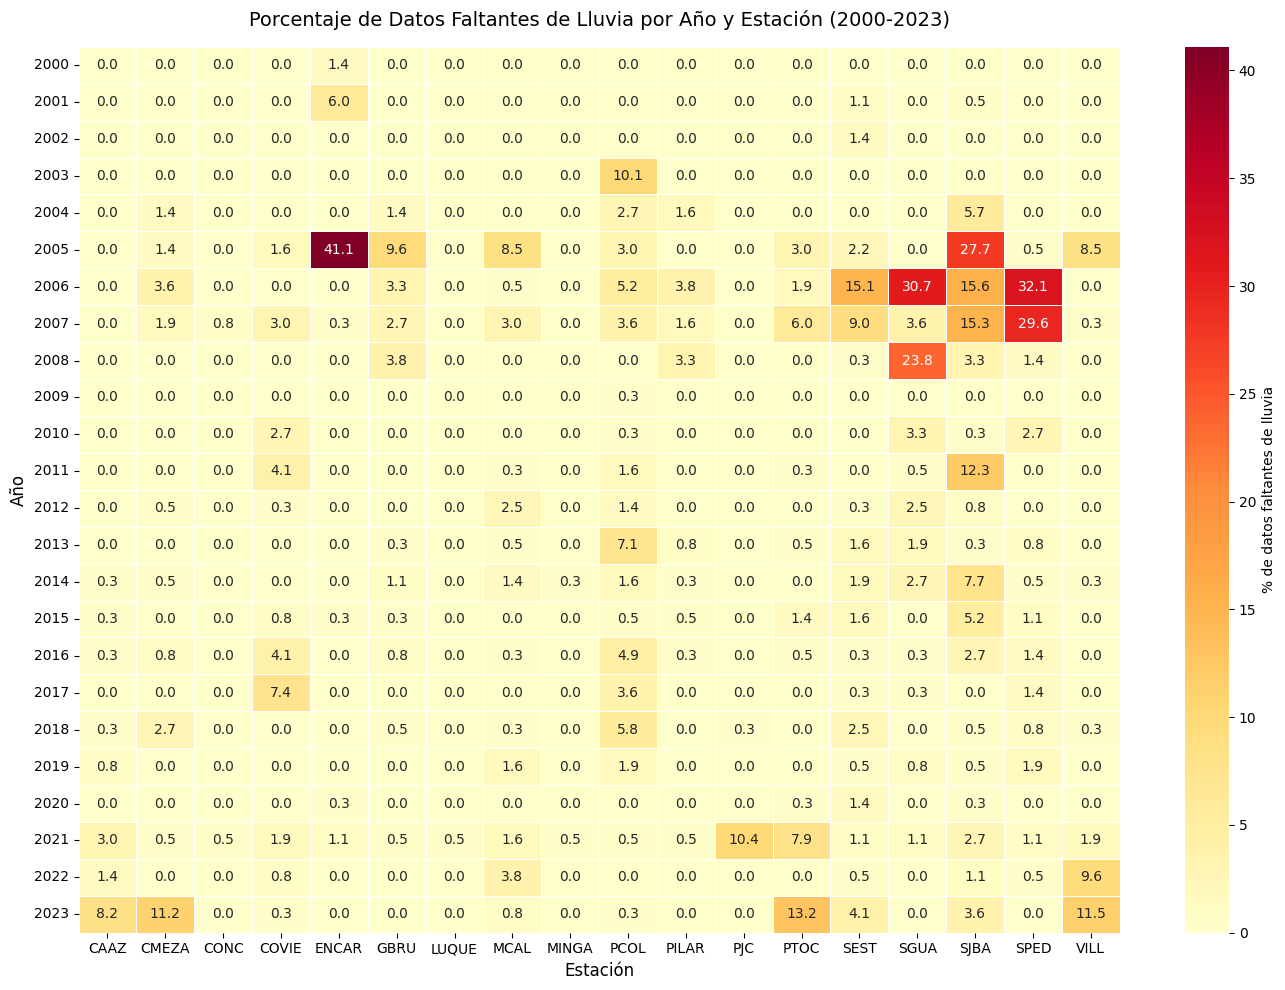

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una columna temporal para el año
df_panel['anio'] = df_panel['fecha'].dt.year

# 2. Calcular el porcentaje de datos faltantes de lluvia por año y estación
resumen_nulos_lluvia = df_panel.groupby(['anio', 'estacion_id'])['lluvia'].apply(
    lambda x: x.isnull().mean() * 100
).unstack()

# 3. Graficar el mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(
    resumen_nulos_lluvia, 
    cmap='YlOrRd',  # Colores cálidos: amarillo (pocos nulos) a rojo (muchos nulos)
    annot=True,     # Muestra el porcentaje numérico en cada celda
    fmt=".1f",      # Formato con un decimal
    linewidths=0.5, 
    cbar_kws={'label': '% de datos faltantes de lluvia'}
)

plt.title('Porcentaje de Datos Faltantes de Lluvia por Año y Estación (2000-2023)', fontsize=14, pad=15)
plt.ylabel('Año', fontsize=12)
plt.xlabel('Estación', fontsize=12)
plt.tight_layout()
plt.show()

# Eliminar la columna auxiliar 'anio' para no alterar el dataframe principal
df_panel = df_panel.drop(columns=['anio'])

##### 1.13.2. Matriz de datos faltantes (Estructura de código de barras)

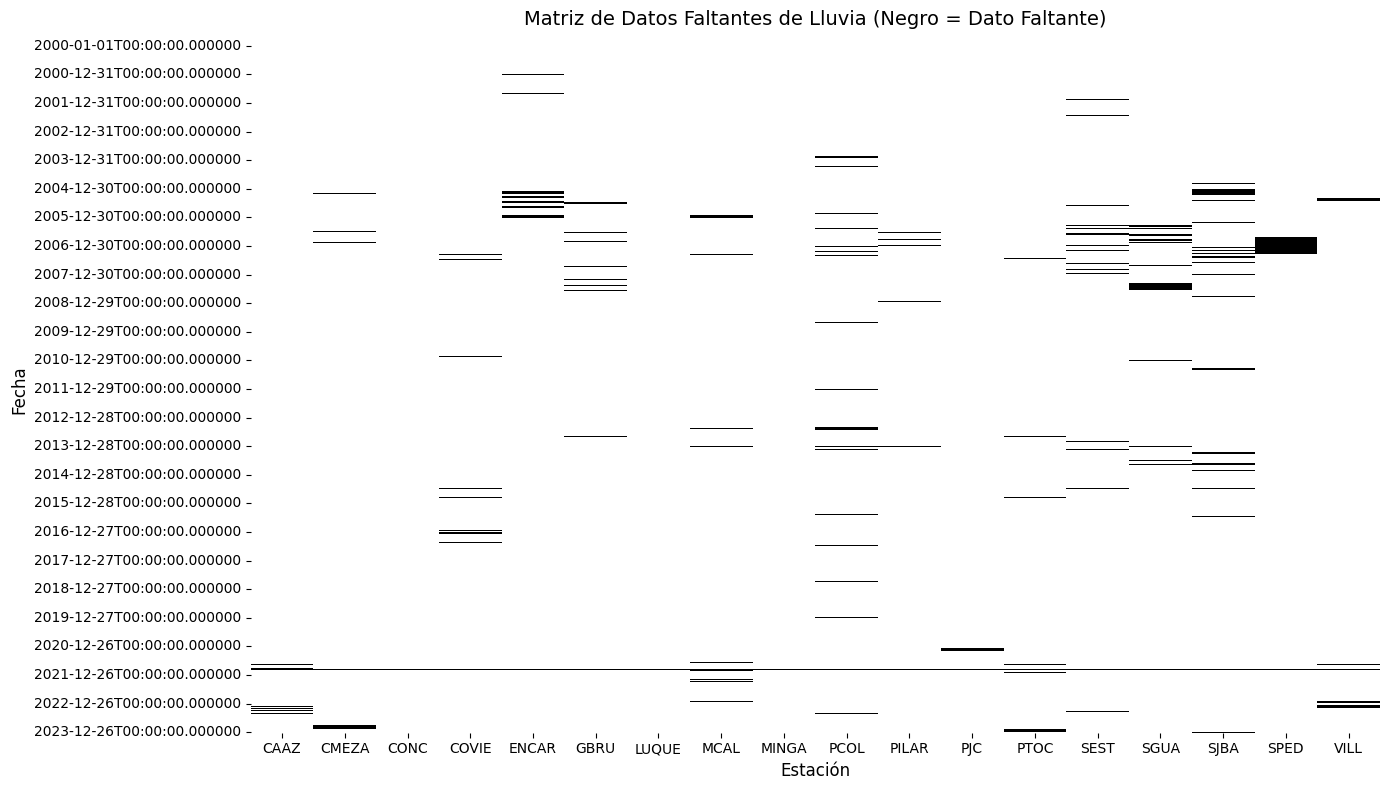

In [38]:
# 1. Pivotar el DataFrame para tener las fechas en las filas y las estaciones en las columnas
df_pivot_lluvia = df_panel.pivot(index='fecha', columns='estacion_id', values='lluvia')

# 2. Graficar la matriz de nulos (True representa nulo)
plt.figure(figsize=(14, 8))
sns.heatmap(
    df_pivot_lluvia.isnull(), 
    cmap='binary',  # Blanco para datos existentes, Negro para datos faltantes (nulos)
    cbar=False, 
    yticklabels=365 # Muestra una etiqueta de fecha aproximadamente cada año en el eje Y
)

plt.title('Matriz de Datos Faltantes de Lluvia (Negro = Dato Faltante)', fontsize=14, pad=15)
plt.ylabel('Fecha', fontsize=12)
plt.xlabel('Estación', fontsize=12)
plt.tight_layout()
plt.show()

##### 1.13.3. Análisis de longitud de vacios de lluvias

In [40]:
# 1. Asegurar orden cronológico
df_panel = df_panel.sort_values(by=['estacion_id', 'fecha']).reset_index(drop=True)

# 2. Identificar bloques de nulos consecutivos en lluvia
is_null_lluvia = df_panel['lluvia'].isnull()
cambio_estacion = df_panel['estacion_id'] != df_panel['estacion_id'].shift()
cambio_estado_nulo = is_null_lluvia != is_null_lluvia.shift()

# Identificador de bloques
bloque_id_lluvia = (cambio_estacion | cambio_estado_nulo).cumsum()

# Calcular tamaños de gaps
gaps_lluvia = df_panel[is_null_lluvia].groupby(bloque_id_lluvia).size()

# 3. Consolidar la frecuencia de los tamaños de brecha
frecuencia_gaps_lluvia = gaps_lluvia.value_counts().reset_index()
frecuencia_gaps_lluvia.columns = ['dias_consecutivos_faltantes', 'cantidad_de_ocurrencias']
frecuencia_gaps_lluvia = frecuencia_gaps_lluvia.sort_values(by='dias_consecutivos_faltantes').reset_index(drop=True)

# Calcular impacto total
total_nulos_lluvia = is_null_lluvia.sum()
frecuencia_gaps_lluvia['total_dias_afectados'] = (
    frecuencia_gaps_lluvia['dias_consecutivos_faltantes'] * 
    frecuencia_gaps_lluvia['cantidad_de_ocurrencias']
)
frecuencia_gaps_lluvia['porcentaje_del_total_faltante'] = (
    frecuencia_gaps_lluvia['total_dias_afectados'] / total_nulos_lluvia
) * 100

print(f"Total de registros faltantes en 'lluvia': {total_nulos_lluvia}")
print("\n--- Distribución de las brechas de datos faltantes (Lluvia) ---")
print(frecuencia_gaps_lluvia.head(20).to_string(index=False))

Total de registros faltantes en 'lluvia': 2239

--- Distribución de las brechas de datos faltantes (Lluvia) ---
 dias_consecutivos_faltantes  cantidad_de_ocurrencias  total_dias_afectados  porcentaje_del_total_faltante
                           1                      794                   794                      35.462260
                           2                       89                   178                       7.949978
                           3                       37                   111                       4.957570
                           4                       17                    68                       3.037070
                           5                        7                    35                       1.563198
                           6                        3                    18                       0.803930
                           7                        8                    56                       2.501117
                           8    

#### 1.14. Agregación mensual con regla de exclusion, se guarda en CSV

In [41]:
import os

# 1. Crear una columna que represente el "Año-Mes" (fijado al primer día de cada mes)
# Esto mantiene la columna como tipo datetime64, ideal para modelos de panel.
df_panel['fecha_mes'] = df_panel['fecha'].dt.to_period('M').dt.to_timestamp()

# 2. Agrupar por estación y mes
grouped = df_panel.groupby(['estacion_id', 'fecha_mes'])

# --- Variable: LLUVIA ---
# Calcular la suma y contar los días válidos (no nulos)
lluvia_suma = grouped['lluvia'].sum()
lluvia_validos = grouped['lluvia'].count()  # .count() excluye automáticamente los NaNs

# Aplicar regla de exclusión: mantener la suma solo si hay al menos 25 días válidos
lluvia_mensual = lluvia_suma.where(lluvia_validos >= 25, np.nan)


# --- Variable: TEMPERATURA MEDIA ---
# Calcular el promedio y contar los días válidos
temp_promedio = grouped['temp_med_imputada'].mean()
temp_validos = grouped['temp_med_imputada'].count()

# Aplicar regla de exclusión: mantener el promedio solo si hay al menos 25 días válidos
temp_mensual = temp_promedio.where(temp_validos >= 25, np.nan)


# 3. Consolidar el DataFrame mensual
df_mensual = pd.DataFrame({
    'lluvia_total': lluvia_mensual,
    'temp_media': temp_mensual
}).reset_index()

# 4. Renombrar y ordenar columnas según lo solicitado
df_mensual = df_mensual.rename(columns={'fecha_mes': 'fecha'})
df_mensual = df_mensual[['estacion_id', 'fecha', 'lluvia_total', 'temp_media']]
df_mensual = df_mensual.sort_values(by=['estacion_id', 'fecha']).reset_index(drop=True)


# --- PASO 5: Guardar el archivo en el directorio correspondiente ---
directorio_salida = "/home/hjvargaso/proyectos/tesis_sequia_2/data/processed"
nombre_archivo = "datos_mensuales_limpios.csv"
ruta_completa = os.path.join(directorio_salida, nombre_archivo)

# Asegurar que el directorio de destino exista
os.makedirs(directorio_salida, exist_ok=True)

# Exportar a CSV (sin índice de filas)
df_mensual.to_csv(ruta_completa, index=False)


# --- PASO 6: Diagnóstico del nuevo dataset mensual ---
print("--- Diagnóstico del nuevo Dataset Mensual ---")
print(f"Ruta de guardado: {ruta_completa}")
print(f"Total de observaciones (meses-estación): {len(df_mensual)}")
print(f"Valores nulos en 'lluvia_total': {df_mensual['lluvia_total'].isnull().sum()}")
print(f"Valores nulos en 'temp_media': {df_mensual['temp_media'].isnull().sum()}")
print("\nMuestra de los primeros 5 registros mensuales:")
print(df_mensual.head())

--- Diagnóstico del nuevo Dataset Mensual ---
Ruta de guardado: /home/hjvargaso/proyectos/tesis_sequia_2/data/processed/datos_mensuales_limpios.csv
Total de observaciones (meses-estación): 5184
Valores nulos en 'lluvia_total': 82
Valores nulos en 'temp_media': 1

Muestra de los primeros 5 registros mensuales:
  estacion_id      fecha  lluvia_total  temp_media
0        CAAZ 2000-01-01         144.0   27.274194
1        CAAZ 2000-02-01          97.6   26.265517
2        CAAZ 2000-03-01         202.8   25.248387
3        CAAZ 2000-04-01         163.6   22.580000
4        CAAZ 2000-05-01         185.8   17.216129


#### 1.15. Estaciones meteorológicas finales

In [4]:
import pandas as pd
import os

df_metadata = pd.read_csv('/home/hjvargaso/proyectos/tesis_sequia_2/data/raw/estaciones_paraguay.csv')

# 1. Eliminar la estación 'PARA' si existe en la metadata
df_metadata = df_metadata[df_metadata['Estación'] != 'PARA'].copy()

# 2. Renombrar la columna de estación para que coincida con 'estacion_id'
df_metadata = df_metadata.rename(columns={'Estación': 'estacion_id'})

# 3. Guardar el archivo en el directorio correspondiente ---
directorio_salida = "/home/hjvargaso/proyectos/tesis_sequia_2/data/processed"
nombre_archivo = "metadata_estaciones_finales.csv"
ruta_completa = os.path.join(directorio_salida, nombre_archivo)

# Asegurar que el directorio de destino exista
os.makedirs(directorio_salida, exist_ok=True)

# Exportar a CSV (sin índice de filas)
df_metadata.to_csv(ruta_completa, index=False)


print(f"\nDataFrame de metadatos guardado exitosamente en: '{nombre_archivo}'")
print(f"Dimensiones: {df_metadata.shape}")
print("\nContenido de la metadata:")
print(df_metadata.head())


DataFrame de metadatos guardado exitosamente en: 'metadata_estaciones_finales.csv'
Dimensiones: (18, 5)

Contenido de la metadata:
  estacion_id                      Nombre_Completo  latitud  longitud  \
0        MCAL  Aeropuerto de Mariscal Estigarribia   -22.03    -60.62   
1        PTOC                        Puerto Casado   -22.16    -57.94   
2         PJC    Aeródromo de Pedro Juan Caballero   -22.64    -55.83   
3        PCOL                        Pozo Colorado   -23.50    -58.79   
4        CONC              Aeródromo de Concepción   -23.44    -57.43   

       region  
0  Occidental  
1  Occidental  
2    Oriental  
3  Occidental  
4    Oriental  
